<a href="https://colab.research.google.com/github/Muskan-Samanta/Car-Price-Prediction/blob/main/CarPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Load dataset ONCE
df = pd.read_csv("/content/cardekho_dataset.csv")

# Keep original copy for market price
original_df = df.copy()

df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [41]:
# Extract numeric values using regex
df['mileage'] = df['mileage'].astype(str).str.extract('(\d+\.?\d*)')[0]
df['engine'] = df['engine'].astype(str).str.extract('(\d+\.?\d*)')[0]
df['max_power'] = df['max_power'].astype(str).str.extract('(\d+\.?\d*)')[0]

# Convert to numeric
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8116/2008751533.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['mileage'] = df['mileage'].astype(str).str.extract('(\d+\.?\d*)')[0]
/tmp/ipykernel_8116/2008751533.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['engine'] = df['engine'].astype(str).str.extract('(\d+\.?\d*)')[0]
/tmp/ipykernel_8116/2008751533.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['max_power'] = df['max_power'].astype(str).str.extract('(\d+\.?\d*)')[0]


In [42]:
# Drop unnecessary column
df.drop(['car_name'], axis=1, inplace=True)

# Example advanced feature
df['power_to_engine'] = df['max_power'] / df['engine']

In [43]:
# Reload the original dataset to ensure all categorical columns are present
df = pd.read_csv("/content/cardekho_dataset.csv")

# Reapply previous preprocessing steps (from cells ynGPxRXePCr2 and lKPOsMqAPFNY)
# Extract numeric values using regex
df['mileage'] = df['mileage'].astype(str).str.extract('(\d+\.?\d*)')[0]
df['engine'] = df['engine'].astype(str).str.extract('(\d+\.?\d*)')[0]
df['max_power'] = df['max_power'].astype(str).str.extract('(\d+\.?\d*)')[0]

# Convert to numeric
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Drop unnecessary column
df.drop(['car_name'], axis=1, inplace=True)

# Example advanced feature
df['power_to_engine'] = df['max_power'] / df['engine']

df = pd.get_dummies(
    df,
    columns=['brand', 'model', 'seller_type', 'transmission_type', 'fuel_type'],
    drop_first=True
)

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8116/2513617720.py:6: SyntaxWarning: invalid escape sequence '\d'
  df['mileage'] = df['mileage'].astype(str).str.extract('(\d+\.?\d*)')[0]
/tmp/ipykernel_8116/2513617720.py:7: SyntaxWarning: invalid escape sequence '\d'
  df['engine'] = df['engine'].astype(str).str.extract('(\d+\.?\d*)')[0]
/tmp/ipykernel_8116/2513617720.py:8: SyntaxWarning: invalid escape sequence '\d'
  df['max_power'] = df['max_power'].astype(str).str.extract('(\d+\.?\d*)')[0]


In [44]:
from sklearn.model_selection import train_test_split

X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()
xgb = XGBRegressor()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [8]:
pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_rf = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))

evaluate("Linear Regression", y_test, pred_lr)
evaluate("Decision Tree", y_test, pred_dt)
evaluate("Random Forest", y_test, pred_rf)
evaluate("XGBoost", y_test, pred_xgb)


Linear Regression
R2 Score: 0.80130712984747
MAE: 176551.74847153743

Decision Tree
R2 Score: 0.87287276547016
MAE: 125891.94777813817

Random Forest
R2 Score: 0.9333824716646624
MAE: 95359.16801816413

XGBoost
R2 Score: 0.91465163230896
MAE: 95870.421875


In [10]:
ensemble_pred = (pred_lr + pred_rf + pred_xgb) / 3
print("Ensemble R2 Score:", r2_score(y_test, ensemble_pred))

Ensemble R2 Score: 0.9396248753879174


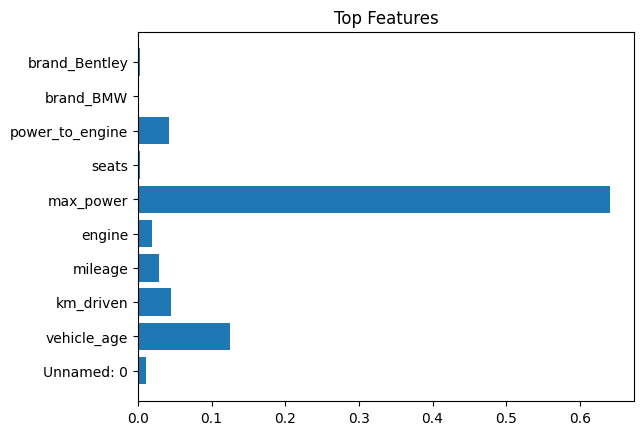

In [11]:
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features[:10], importances[:10])
plt.title("Top Features")
plt.show()

In [12]:
import ipywidgets as widgets
from IPython.display import display

vehicle_age = widgets.IntSlider(min=0, max=20, description="Age")
km_driven = widgets.IntText(description="KM Driven")
mileage = widgets.FloatText(description="Mileage")
engine = widgets.FloatText(description="Engine")
max_power = widgets.FloatText(description="Power")
seats = widgets.IntSlider(min=2, max=10, description="Seats")

# ✅ ADD HERE
brand_widget = widgets.Text(description="Brand:")
model_widget = widgets.Text(description="Model:")

seller_type = widgets.Dropdown(options=['Dealer','Individual'])
transmission = widgets.Dropdown(options=['Manual','Automatic'])

button = widgets.Button(description="Predict")
output = widgets.Output()

In [13]:
def predict(b):
    output.clear_output()

    input_dict = dict.fromkeys(X.columns, 0)

    input_dict['vehicle_age'] = vehicle_age.value
    input_dict['km_driven'] = km_driven.value
    input_dict['mileage'] = mileage.value
    input_dict['engine'] = engine.value
    input_dict['max_power'] = max_power.value
    input_dict['seats'] = seats.value
    input_dict['power_to_engine'] = max_power.value / engine.value

    if f"seller_type_{seller_type.value}" in input_dict:
        input_dict[f"seller_type_{seller_type.value}"] = 1

    if f"transmission_type_{transmission.value}" in input_dict:
        input_dict[f"transmission_type_{transmission.value}"] = 1

    input_array = np.array(list(input_dict.values())).reshape(1, -1)

    prediction = rf.predict(input_array)

    with output:
        print(f"🚗 Predicted Price: ₹ {prediction[0]:.2f} Lakhs")

In [14]:
original_df = pd.read_csv("/content/cardekho_dataset.csv")
brand_options = sorted(original_df['brand'].dropna().unique())
model_options = sorted(original_df['model'].dropna().unique())
# original_df can be garbage collected now

In [15]:
brand_widget = widgets.Dropdown(
    options=sorted(original_df['brand'].unique()),
    description='Brand:'
)

model_widget = widgets.Dropdown(
    options=sorted(original_df['model'].unique()),
    description='Model:'
)

In [16]:
def update_models(change):
    selected_brand = change['new']

    # Use original_df which still has 'brand' and 'model' columns
    filtered_models = original_df[original_df['brand'] == selected_brand]['model'].dropna().unique()

    model_widget.options = sorted(filtered_models)

brand_widget.observe(update_models, names='value')

In [17]:
def predict(b):
    output.clear_output()

    input_dict = dict.fromkeys(X.columns, 0)

    # Numeric inputs
    input_dict['vehicle_age'] = vehicle_age.value
    input_dict['km_driven'] = km_driven.value
    input_dict['mileage'] = mileage.value
    input_dict['engine'] = engine.value
    input_dict['max_power'] = max_power.value
    input_dict['seats'] = seats.value
    input_dict['power_to_engine'] = max_power.value / engine.value

    # Convert WORD → encoded column
    brand_col = f"brand_{brand_widget.value}"
    model_col = f"model_{model_widget.value}"
    seller_col = f"seller_type_{seller_type.value}"
    trans_col = f"transmission_type_{transmission.value}"

    for col in [brand_col, model_col, seller_col, trans_col]:
        if col in input_dict:
            input_dict[col] = 1

    # Convert to array
    input_array = np.array(list(input_dict.values())).reshape(1, -1)

    prediction = rf.predict(input_array)

    with output:
        print("🚗 Selected Car:")
        print(f"Brand: {brand_widget.value}")
        print(f"Model: {model_widget.value}")
        print(f"Transmission: {transmission.value}")
        print(f"Seller: {seller_type.value}")
        print(f"\n💰 Predicted Price: ₹ {prediction[0]:.2f} Lakhs")

In [18]:
def get_market_price(brand, model):
    filtered = original_df[
        (original_df['brand'] == brand) &
        (original_df['model'] == model)
    ]

    if len(filtered) > 0:
        return filtered['selling_price'].mean()
    else:
        return None

In [19]:
def check_deal(pred_price, market_price):
    if market_price is None:
        return "⚠️ No market data available"

    diff = pred_price - market_price

    # Threshold = 10%
    threshold = 0.1 * market_price

    if diff < -threshold:
        return "✅ Best Deal"
    elif abs(diff) <= threshold:
        return "⚖️ Fair Price"
    else:
        return "❌ Overpriced"

In [20]:
def predict(b):
    output.clear_output()

    input_dict = dict.fromkeys(X.columns, 0)

    # Numeric inputs
    input_dict['vehicle_age'] = vehicle_age.value
    input_dict['km_driven'] = km_driven.value
    input_dict['mileage'] = mileage.value
    input_dict['engine'] = engine.value
    input_dict['max_power'] = max_power.value
    input_dict['seats'] = seats.value
    input_dict['power_to_engine'] = max_power.value / engine.value

    # Encoding

    brand_col = f"brand_{brand_widget.value}"
    model_col = f"model_{model_widget.value}"
    seller_col = f"seller_type_{seller_type.value}"
    trans_col = f"transmission_type_{transmission.value}"

    for col in [brand_col, model_col, seller_col, trans_col]:
        if col in input_dict:
            input_dict[col] = 1

    input_array = np.array(list(input_dict.values())).reshape(1, -1)

    # Predict
    prediction = rf.predict(input_array)[0]

    # Market price
    market_price = get_market_price(brand_widget.value, model_widget.value)

    # Deal status
    deal_status = check_deal(prediction, market_price)

    with output:
        print("🚗 Selected Car:")
        print(f"Brand: {brand_widget.value}")
        print(f"Model: {model_widget.value}")

        print("\n💰 Predicted Price: ₹ {:.2f} Lakhs".format(prediction))

        if market_price:
            print("📊 Market Avg Price: ₹ {:.2f} Lakhs".format(market_price))

        print("\n🔥 Deal Status:", deal_status)

In [21]:
from IPython.display import HTML

In [22]:
def get_color(deal_status):
    if "Best Deal" in deal_status:
        return "green"
    elif "Fair Price" in deal_status:
        return "orange"
    elif "Overpriced" in deal_status:
        return "red"
    else:
        return "black"

In [23]:
def predict(b):
    output.clear_output()

    input_dict = dict.fromkeys(X.columns, 0)

    # Numeric inputs
    input_dict['vehicle_age'] = vehicle_age.value
    input_dict['km_driven'] = km_driven.value
    input_dict['mileage'] = mileage.value
    input_dict['engine'] = engine.value
    input_dict['max_power'] = max_power.value
    input_dict['seats'] = seats.value
    input_dict['power_to_engine'] = max_power.value / engine.value

    # Encoding
    brand_col = f"brand_{brand_widget.value}"
    model_col = f"model_{model_widget.value}"
    seller_col = f"seller_type_{seller_type.value}"
    trans_col = f"transmission_type_{transmission.value}"

    for col in [brand_col, model_col, seller_col, trans_col]:
        if col in input_dict:
            input_dict[col] = 1

    input_array = np.array(list(input_dict.values())).reshape(1, -1)

    # Prediction
    prediction = rf.predict(input_array)[0]

    # Market price
    market_price = get_market_price(brand_widget.value, model_widget.value)

    # Deal status
    deal_status = check_deal(prediction, market_price)

    # Color
    color = get_color(deal_status)

    with output:
        display(HTML(f"""
        <div style="border:2px solid #ddd; padding:15px; border-radius:10px">
            <h3>🚗 Selected Car</h3>
            <p><b>Brand:</b> {brand_widget.value}</p>
            <p><b>Model:</b> {model_widget.value}</p>

            <h3>💰 Price Prediction</h3>
            <p><b>Predicted Price:</b> ₹ {prediction:.2f} Lakhs</p>
            <p><b>Market Price:</b> ₹ {market_price:.2f} Lakhs</p>

            <h2 style="color:{color};">🔥 {deal_status}</h2>
        </div>
        """))

In [24]:
import time

In [25]:
def predict(b):
    output.clear_output()

    with output:
        display(HTML("""
        <div style="text-align:center;">
            <h3>⏳ Analyzing Car Data...</h3>
            <div style="
                border: 6px solid #f3f3f3;
                border-top: 6px solid #3498db;
                border-radius: 50%;
                width: 50px;
                height: 50px;
                animation: spin 1s linear infinite;
                margin: auto;
            "></div>

            <style>
            @keyframes spin {
                0% { transform: rotate(0deg); }
                100% { transform: rotate(360deg); }
            }
            </style>
        </div>
        """))

    # Simulate loading delay (optional but nice)
    time.sleep(2)

    output.clear_output()

    # ====== Prediction Logic ======
    input_dict = dict.fromkeys(X.columns, 0)

    input_dict['vehicle_age'] = vehicle_age.value
    input_dict['km_driven'] = km_driven.value
    input_dict['mileage'] = mileage.value
    input_dict['engine'] = engine.value
    input_dict['max_power'] = max_power.value
    input_dict['seats'] = seats.value
    input_dict['power_to_engine'] = max_power.value / engine.value

    brand_col = f"brand_{brand_widget.value}"
    model_col = f"model_{model_widget.value}"
    seller_col = f"seller_type_{seller_type.value}"
    trans_col = f"transmission_type_{transmission.value}"

    for col in [brand_col, model_col, seller_col, trans_col]:
        if col in input_dict:
            input_dict[col] = 1

    input_array = np.array(list(input_dict.values())).reshape(1, -1)

    prediction = rf.predict(input_array)[0]
    market_price = get_market_price(brand_widget.value, model_widget.value)
    deal_status = check_deal(prediction, market_price)
    color = get_color(deal_status)

    # ====== Final Output ======
    with output:
        display(HTML(f"""
        <div style="border:2px solid #ddd; padding:15px; border-radius:10px">
            <h3>🚗 Selected Car</h3>
            <p><b>Brand:</b> {brand_widget.value}</p>
            <p><b>Model:</b> {model_widget.value}</p>

            <h3>💰 Price Prediction</h3>
            <p><b>Predicted Price:</b> ₹ {prediction:.2f} Lakhs</p>
            <p><b>Market Price:</b> ₹ {market_price:.2f} Lakhs</p>

            <h2 style="color:{color};">🔥 {deal_status}</h2>
        </div>
        """))

In [26]:
from IPython.display import HTML, display

display(HTML("""
<style>
.app-container {
    background: #1e1e2f;
    padding: 20px;
    border-radius: 15px;
    font-family: Arial;
    color: #ffffff;
}

.card {
    background: #2c2c3e;
    padding: 15px;
    margin: 10px 0;
    border-radius: 12px;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.4);
    color: #ffffff;
}

.title {
    text-align: center;
    font-size: 28px;
    font-weight: bold;
    color: #00d4ff;
}

.subtitle {
    text-align: center;
    color: #bbbbbb;
    margin-bottom: 15px;
}

.app-container {
    color: white;
}

button {
    background-color: #00d4ff !important;
    color: black !important;
    border-radius: 8px !important;
    font-weight: bold;
}

</style>

<div class="app-container">
    <div class="title">🚗 Smart Car Price Predictor</div>
    <div class="subtitle">AI-powered valuation & deal analysis</div>
</div>
"""))

In [27]:
import numpy as np

def get_confidence(preds):
    std = np.std(preds)
    confidence = max(0, min(100, 100 - (std * 10)))
    return round(confidence, 2)

In [28]:
# This cell's content has been moved into the predict function.

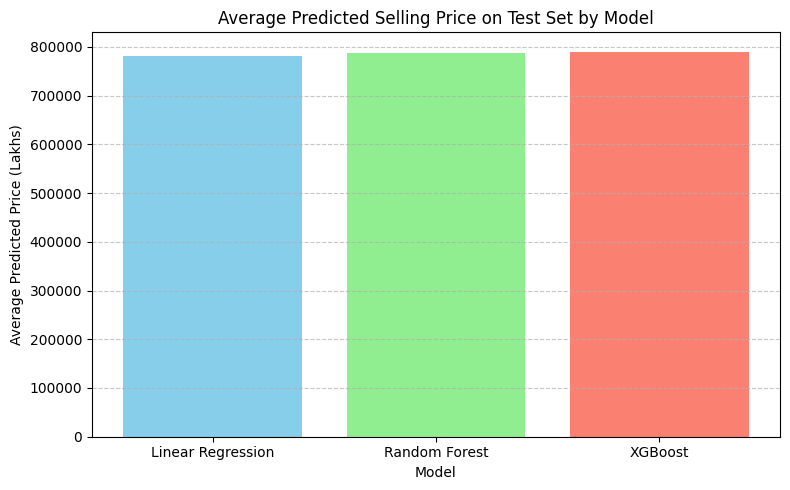

In [29]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for mean calculation

plt.figure(figsize=(8, 5))
# Calculate the mean of the predictions for the test set from each model
mean_preds = [np.mean(pred_lr), np.mean(pred_rf), np.mean(pred_xgb)]
plt.bar(["Linear Regression", "Random Forest", "XGBoost"], mean_preds, color=['skyblue', 'lightgreen', 'salmon'])
plt.title("Average Predicted Selling Price on Test Set by Model")
plt.xlabel("Model")
plt.ylabel("Average Predicted Price (Lakhs)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
with output:
    print("📊 Model Comparison")
    display(plt.gcf())

<Figure size 640x480 with 0 Axes>

In [31]:
def plot_depreciation(brand, model):
    filtered = original_df[
        (original_df['brand'] == brand) &
        (original_df['model'] == model)
    ]

    if len(filtered) > 0:
        avg_price = filtered.groupby('vehicle_age')['selling_price'].mean()

        plt.figure()
        avg_price.plot()
        plt.title("📉 Price Depreciation Over Age")
        plt.xlabel("Car Age")
        plt.ylabel("Price")
        plt.show()

In [32]:
plot_depreciation(brand_widget.value, model_widget.value)

In [33]:
# This cell's content is redundant as the display logic is already handled by the 'predict' function in cell 6ArlgOFJaHNk.
# It was causing a NameError because the variables 'prediction', 'confidence', 'market_price', 'color', and 'deal_status'
# are local to the 'predict' function and not defined in the global scope or within this cell's execution context.

# with output:
#     display(HTML(f"""
#     <div style="
#        background:#2c2c3e;
#        color:white;
#        padding:20px;
#        border-radius:12px;
#     ">
#         <h2>🚗 {brand_widget.value} {model_widget.value}</h2>

#         <p>💰 <b>Predicted Price:</b> ₹ {prediction:.2f} Lakhs</p>
#         <p>📊 <b>Confidence:</b> {confidence}%</p>
#         <p>📊 <b>Market Price:</b> ₹ {market_price:.2f} Lakhs</p>

#         <h2 style="color:{color};">🔥 {deal_status}</h2>
#     </div>
#     """))

In [34]:
def get_val(x):
    return x.value if hasattr(x, 'value') else x

In [35]:
def predict(b):
    output.clear_output()

    import numpy as np
    from IPython.display import HTML

    input_dict = dict.fromkeys(X.columns, 0)

    # Safe values
    engine_val = engine.value
    power_val = max_power.value

    input_dict['vehicle_age'] = get_val(vehicle_age)
    input_dict['km_driven'] = get_val(km_driven)
    input_dict['mileage'] = get_val(mileage)
    input_dict['engine'] = engine_val
    input_dict['max_power'] = power_val
    input_dict['seats'] = get_val(seats)

    # ✅ Safe division
    if engine_val == 0:
        input_dict['power_to_engine'] = 0
    else:
        input_dict['power_to_engine'] = power_val / engine_val

    # Encoding
    for col in [
        f"brand_{brand_widget.value}",
        f"model_{model_widget.value}",
        f"seller_type_{seller_type.value}",
        f"transmission_type_{transmission.value}"
    ]:
        if col in input_dict:
            input_dict[col] = 1

    input_array = np.array(list(input_dict.values())).reshape(1, -1)

    # Predictions
    pred_lr = lr.predict(input_array)[0]
    pred_rf = rf.predict(input_array)[0]
    pred_xgb = xgb.predict(input_array)[0]

    all_preds = [pred_lr, pred_rf, pred_xgb]
    prediction = np.mean(all_preds)

    confidence = round(max(0, min(100, 100 - np.std(all_preds)*10)), 2)

    market_price = get_market_price(brand_widget.value, model_widget.value)

    deal_status = check_deal(prediction, market_price)
    color = get_color(deal_status)

    # ✅ Market safe display
    market_html = f"₹ {market_price:.2f} Lakhs" if market_price else "No Data"

    with output:
        display(HTML(f"""
        <div class="app-container">
            <div style="
                background:#2c2c3e;
                color:white;
                padding:20px;
                border-radius:12px;
            ">
                <h2>🚗 {brand_widget.value} {model_widget.value}</h2>

                <p>💰 <b>Predicted Price:</b> ₹ {prediction:.2f} Lakhs</p>
                <p>📊 <b>Confidence:</b> {confidence}%</p>
                <p>📊 <b>Market Price:</b> {market_html}</p>

                <h2 style="color:{color};">🔥 {deal_status}</h2>
            </div>
        </div>
        """))

In [36]:
button.on_click(predict)

In [37]:
ui = widgets.VBox([
    widgets.HTML('<div class="card"><b>Select Car Details</b></div>'),

    brand_widget,
    model_widget,

    widgets.HTML('<div class="card"><b>Car Specifications</b></div>'),

    vehicle_age,
    km_driven,
    mileage,
    engine,
    max_power,
    seats,

    widgets.HTML('<div class="card"><b>Other Details</b></div>'),

    seller_type,
    transmission,

    button,
    output
])

In [38]:
display(ui)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
